# 03 — RNN model in TensorFlow / Keras

This notebook builds an RNN-based model for the competition.

Goals:
1. Demonstrate a deep-learning text model using **Embedding + GRU**
2. Train **two separate models**:
   - `Rating` as a regression problem
   - `Recommended` as a binary classification problem
3. Evaluate both models using **Spearman correlation**
4. Create a **Kaggle-valid submission**

In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("tensorflow") is None:
    print("TensorFlow not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.1


In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [5]:
train = pd.read_csv("../data/rawdata/train.csv")
test = pd.read_csv("../data/rawdata/test.csv")
sample_sub = pd.read_csv("../data/rawdata/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_sub.shape)


Train shape: (14091, 10)
Test shape: (9395, 8)
Sample submission shape: (9395, 3)


## 1. Text preprocessing

For the RNN model we keep preprocessing light.

We will:
- preserve missingness information
- fill missing text with empty strings
- clean text lightly
- combine title and review
- add marker words like `missingtitle` / `missingreview`

In [6]:
def clean_text(text):
    """
    Light text cleaning:
    - convert to string
    - lowercase
    - remove non-alphanumeric symbols except apostrophes
    - remove extra spaces
    """
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = text.lower()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_reviews_rnn(df):
    df = df.copy()
    
    # Keep missingness information
    df["title_missing"] = df["Review_Title"].isna().astype(int)
    df["review_missing"] = df["Review"].isna().astype(int)
    
    # Fill missing text so the tokenizer can process it
    df["Review_Title"] = df["Review_Title"].fillna("")
    df["Review"] = df["Review"].fillna("")
    
    # Light cleaning
    df["Review_Title_clean"] = df["Review_Title"].apply(clean_text)
    df["Review_clean"] = df["Review"].apply(clean_text)
    
    # Marker tokens so the RNN can learn if text was missing
    df["title_prefix"] = np.where(df["title_missing"] == 1, "missingtitle ", "hastitle ")
    df["review_prefix"] = np.where(df["review_missing"] == 1, "missingreview ", "hasreview ")
    
    # Combine title + review into one text field
    df["full_text"] = (
        df["title_prefix"] +
        "title " + df["Review_Title_clean"] + " " +
        df["review_prefix"] +
        "review " + df["Review_clean"]
    ).str.strip()
    
    return df

In [7]:
train_p = preprocess_reviews_rnn(train)
test_p = preprocess_reviews_rnn(test)

In [8]:
train_p[[
    "Review_Title", "Review",
    "title_missing", "review_missing",
    "full_text"
]].head(10)

,Review_Title,Review,title_missing,review_missing,full_text
0,Cute fall/holiday top,"Love this top! the quality is magnificent and the pattern is even cuter in person. i'm 5'4"", 125 lbs and bought my normal size s which fits excellently. it's pretty flouncy and roomy, which is nic...",0,0,hastitle title cute fall holiday top hasreview review love this top the quality is magnificent and the pattern is even cuter in person i'm 5'4 125 lbs and bought my normal size s which fits excell...
1,,,1,1,missingtitle title missingreview review
2,Disappointed,"Sleeves were tight, was difficult to put on ?. for the price, you want to love the shirt. sending it back.",0,0,hastitle title disappointed hasreview review sleeves were tight was difficult to put on for the price you want to love the shirt sending it back
3,Gorgeous detailing,"I never write reviews but this clothe is so fantastic i felt compelled to write one. it has unbelievably gorgeous detailing, from delicate beading and sequins on the bodice to the three layers of ...",0,0,hastitle title gorgeous detailing hasreview review i never write reviews but this clothe is so fantastic i felt compelled to write one it has unbelievably gorgeous detailing from delicate beading ...
4,Cute and comfortable tee!,Love this tshirt! casual but can be clotheed up with wedges and a scarf!,0,0,hastitle title cute and comfortable tee hasreview review love this tshirt casual but can be clotheed up with wedges and a scarf
5,Disappointed,"I was so smitten by this shirt when i saw it online. i love embroidery and purple is my preferred color. i am a size 10 and decided to order an l. the shoulders fit well, but the rest of it was hu...",0,0,hastitle title disappointed hasreview review i was so smitten by this shirt when i saw it online i love embroidery and purple is my preferred color i am a size 10 and decided to order an l the sho...
6,,"Love these jeans!! i ordered one pair and liked them so much i ordered another right away! i ordered the 26 regular.\nyes, they are too long (i'm 5'4 1/2""# for flats, but look fantastic with heels...",1,0,missingtitle title hasreview review love these jeans i ordered one pair and liked them so much i ordered another right away i ordered the 26 regular yes they are too long i'm 5'4 1 2 for flats bu...
7,Very large; lace is kinda coarse,"Thought i'd love this top; i'm a sucker for lace anything from retailer. but i found the lace, while pretty, to be quite rough, which to me indicates a lower quality. and i guess i should've know...",0,0,hastitle title very large lace is kinda coarse hasreview review thought i'd love this top i'm a sucker for lace anything from retailer but i found the lace while pretty to be quite rough which to ...
8,My new preferred jean!,"Paige denim has done it again with this version of the hoxton high rise. no matter how many times i tell myself that i will find a less expensive pair of jeans, i never can find jeans that fit as ...",0,0,hastitle title my new preferred jean hasreview review paige denim has done it again with this version of the hoxton high rise no matter how many times i tell myself that i will find a less expensi...
9,Pirate sleeves,"The beadwork is gorgeous, but the sleeves are so puffy, it looks as though you're wearing shoulder pads. the fabric of the shirt isn't that fabulous either.",0,0,hastitle title pirate sleeves hasreview review the beadwork is gorgeous but the sleeves are so puffy it looks as though you're wearing shoulder pads the fabric of the shirt isn't that fabulous either


## 2. Train / validation split

We create a validation split so we can compare strategies before generating the final submission.

In [9]:
stratify_label = train_p["Rating"].astype(str) + "_" + train_p["Recommended"].astype(str)

try:
    train_df, val_df = train_test_split(
        train_p,
        test_size=0.2,
        random_state=SEED,
        stratify=stratify_label
    )
except ValueError:
    train_df, val_df = train_test_split(
        train_p,
        test_size=0.2,
        random_state=SEED,
        stratify=train_p["Recommended"]
    )

print("Train split:", train_df.shape)
print("Validation split:", val_df.shape)

Train split: (11272, 17)
Validation split: (2819, 17)


In [10]:
X_train_text = train_df["full_text"].values
X_val_text = val_df["full_text"].values
X_test_text = test_p["full_text"].values

y_train_rating = train_df["Rating"].values.astype("float32")
y_val_rating = val_df["Rating"].values.astype("float32")

y_train_rec = train_df["Recommended"].values.astype("float32")
y_val_rec = val_df["Recommended"].values.astype("float32")

## 3. Tokenization and padding

RNNs do not work on raw text strings directly.

We need to:
1. build a vocabulary
2. convert text into integer sequences
3. pad sequences to equal length

In [11]:
MAX_WORDS = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

print("Full vocabulary size:", len(tokenizer.word_index))
print("Using capped vocabulary size:", MAX_WORDS)

Full vocabulary size: 11144
Using capped vocabulary size: 20000


In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [ ]:
# Analyze sequence lengths to choose a reasonable maxlen for padding
train_seq_lengths = np.array([len(seq) for seq in X_train_seq])

pd.Series(train_seq_lengths).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    11272.000000
mean        64.613556
std         30.962670
min          4.000000
50%         64.000000
75%         94.000000
90%        106.000000
95%        109.000000
99%        115.000000
max        123.000000
dtype: float64

In [14]:
MAX_LEN = int(np.percentile(train_seq_lengths, 95))
MAX_LEN = min(MAX_LEN, 150)

print("Chosen MAX_LEN:", MAX_LEN)

Chosen MAX_LEN: 109


In [15]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (11272, 109)
X_val_pad shape: (2819, 109)
X_test_pad shape: (9395, 109)


In [16]:
## 4. Evaluation helpers
#The competition uses mean columnwise Spearman correlation.

def safe_spearman(y_true, y_pred):
    score = spearmanr(y_true, y_pred).statistic
    if pd.isna(score):
        return 0.0
    return float(score)


def evaluate_predictions(y_true_rating, y_pred_rating, y_true_rec, y_pred_rec):
    rating_score = safe_spearman(y_true_rating, y_pred_rating)
    rec_score = safe_spearman(y_true_rec, y_pred_rec)
    mean_score = (rating_score + rec_score) / 2
    
    return pd.DataFrame({
        "target": ["Rating", "Recommended", "Mean"],
        "spearman": [rating_score, rec_score, mean_score]
    })

## 5. Build the models

We use the same general class style:
- `Sequential`
- `Embedding`
- `GRU`
- `Dense`
- output layer

In [18]:
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("Vocabulary size used by model:", vocab_size)

Vocabulary size used by model: 11145


In [21]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

rating_model = Sequential()
rating_model.add(Input(shape=(MAX_LEN,)))
rating_model.add(Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True))
rating_model.add(GRU(64))
rating_model.add(Dense(32, activation="relu"))
rating_model.add(Dropout(0.3))
rating_model.add(Dense(1, activation="linear"))

rating_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

rating_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 109, 64)        │       713,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,353 (2.82 MB)

 Trainable params: 740,353 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
recommended_model = Sequential()
recommended_model.add(Input(shape=(MAX_LEN,)))
recommended_model.add(Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True))
recommended_model.add(GRU(64))
recommended_model.add(Dense(32, activation="relu"))
recommended_model.add(Dropout(0.3))
recommended_model.add(Dense(1, activation="sigmoid"))

recommended_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

recommended_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 109, 64)        │       713,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,353 (2.82 MB)

 Trainable params: 740,353 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training setup

We use `EarlyStopping`, which is directly in line with the callbacks material from class. :contentReference[oaicite:3]{index=3}

In [23]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [24]:
classes = np.unique(y_train_rec.astype(int))
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_rec.astype(int)
)

class_weight_rec = {int(c): float(w) for c, w in zip(classes, weights)}
class_weight_rec

{0: 2.818, 1: 0.6078515962036238}

In [25]:
## 7. Fit the rating model

history_rating = rating_model.fit(
    X_train_pad,
    y_train_rating,
    epochs=15,
    validation_data=(X_val_pad, y_val_rating),
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping]
)

Epoch 1/15


2026-05-06 17:05:20.935837: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


177/177 - 16s - 90ms/step - loss: 3.0324 - mae: 1.3309 - val_loss: 1.3571 - val_mae: 0.9508
Epoch 2/15
177/177 - 6s - 32ms/step - loss: 1.5926 - mae: 1.0054 - val_loss: 1.2364 - val_mae: 0.9057
Epoch 3/15
177/177 - 7s - 37ms/step - loss: 1.5075 - mae: 0.9839 - val_loss: 1.1952 - val_mae: 0.8809
Epoch 4/15
177/177 - 5s - 31ms/step - loss: 1.0681 - mae: 0.8127 - val_loss: 0.5426 - val_mae: 0.5271
Epoch 5/15
177/177 - 6s - 31ms/step - loss: 0.7356 - mae: 0.6742 - val_loss: 0.5377 - val_mae: 0.5683
Epoch 6/15
177/177 - 6s - 31ms/step - loss: 0.6591 - mae: 0.6376 - val_loss: 0.4936 - val_mae: 0.5173
Epoch 7/15
177/177 - 6s - 34ms/step - loss: 0.5945 - mae: 0.6083 - val_loss: 0.5344 - val_mae: 0.5037
Epoch 8/15
177/177 - 6s - 32ms/step - loss: 0.5565 - mae: 0.5852 - val_loss: 0.5001 - val_mae: 0.5085
Epoch 9/15
177/177 - 6s - 31ms/step - loss: 0.5303 - mae: 0.5731 - val_loss: 0.5010 - val_mae: 0.5168


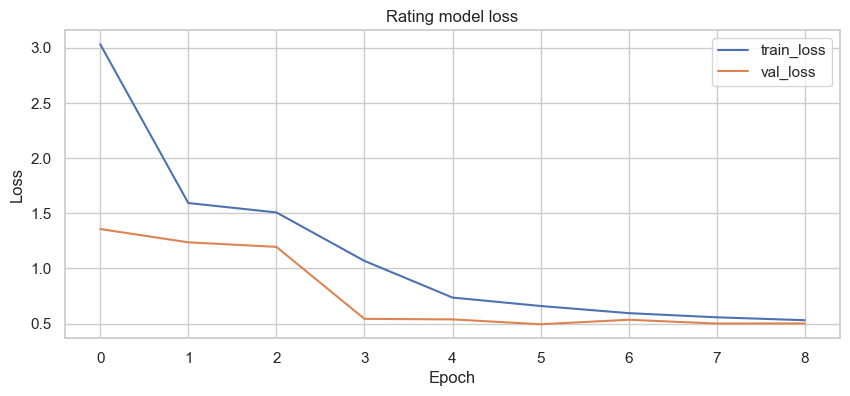

In [26]:
rating_history_df = pd.DataFrame(history_rating.history)

plt.figure(figsize=(10, 4))
plt.plot(rating_history_df["loss"], label="train_loss")
plt.plot(rating_history_df["val_loss"], label="val_loss")
plt.title("Rating model loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [27]:
## 8. Fit the recommendation model

history_rec = recommended_model.fit(
    X_train_pad,
    y_train_rec,
    epochs=15,
    validation_data=(X_val_pad, y_val_rec),
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping],
    class_weight=class_weight_rec
)

Epoch 1/15
177/177 - 10s - 55ms/step - accuracy: 0.5332 - loss: 0.6948 - val_accuracy: 0.8216 - val_loss: 0.6912
Epoch 2/15
177/177 - 6s - 32ms/step - accuracy: 0.4685 - loss: 0.6924 - val_accuracy: 0.2316 - val_loss: 0.7214
Epoch 3/15
177/177 - 6s - 32ms/step - accuracy: 0.4882 - loss: 0.6836 - val_accuracy: 0.7992 - val_loss: 0.5374


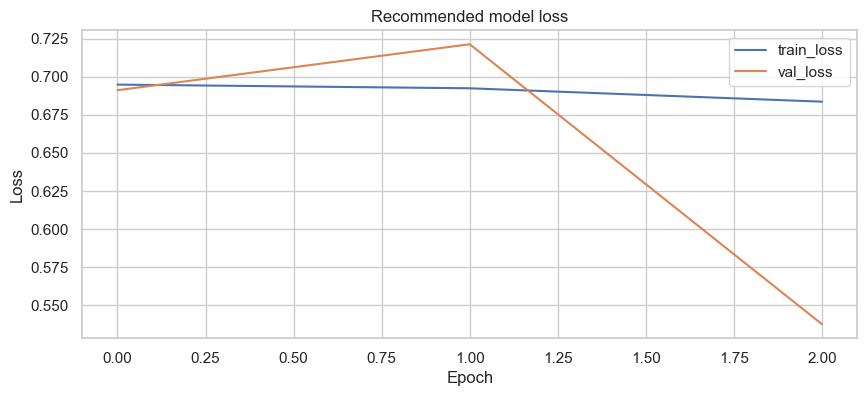

In [28]:
rec_history_df = pd.DataFrame(history_rec.history)

plt.figure(figsize=(10, 4))
plt.plot(rec_history_df["loss"], label="train_loss")
plt.plot(rec_history_df["val_loss"], label="val_loss")
plt.title("Recommended model loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 9. Validation predictions and strategy comparison

As in the Bag-of-Words notebook, we compare:
- continuous vs rounded `Rating`
- probability vs hard-label `Recommended`

In [29]:
val_rating_pred_cont = rating_model.predict(X_val_pad, verbose=0).ravel()
val_rating_pred_cont = np.clip(val_rating_pred_cont, 1, 5)

val_rating_pred_round = np.clip(np.rint(val_rating_pred_cont), 1, 5).astype(int)

val_rec_pred_prob = recommended_model.predict(X_val_pad, verbose=0).ravel()
val_rec_pred_label = (val_rec_pred_prob >= 0.5).astype(int)

In [30]:
results = []

rating_options = {
    "rating_continuous": val_rating_pred_cont,
    "rating_rounded": val_rating_pred_round
}

rec_options = {
    "rec_probability": val_rec_pred_prob,
    "rec_hard_label": val_rec_pred_label
}

for rating_name, rating_pred in rating_options.items():
    for rec_name, rec_pred in rec_options.items():
        score_df = evaluate_predictions(
            y_val_rating, rating_pred,
            y_val_rec, rec_pred
        )
        mean_score = score_df.loc[score_df["target"] == "Mean", "spearman"].iloc[0]
        
        results.append({
            "rating_prediction_type": rating_name,
            "recommended_prediction_type": rec_name,
            "mean_spearman": mean_score,
            "rating_spearman": score_df.loc[score_df["target"] == "Rating", "spearman"].iloc[0],
            "recommended_spearman": score_df.loc[score_df["target"] == "Recommended", "spearman"].iloc[0]
        })

results_df = pd.DataFrame(results).sort_values("mean_spearman", ascending=False)
results_df

,rating_prediction_type,recommended_prediction_type,mean_spearman,rating_spearman,recommended_spearman
1,rating_continuous,rec_hard_label,0.376000,0.696068,0.055932
3,rating_rounded,rec_hard_label,0.374836,0.693740,0.055932
0,rating_continuous,rec_probability,0.355828,0.696068,0.015587
2,rating_rounded,rec_probability,0.354664,0.693740,0.015587


In [31]:
best_row = results_df.iloc[0]
best_row

rating_prediction_type         rating_continuous
recommended_prediction_type       rec_hard_label
mean_spearman                              0.376
rating_spearman                         0.696068
recommended_spearman                    0.055932
Name: 1, dtype: object

In [32]:
kaggle_valid_results = results_df[results_df["rating_prediction_type"] == "rating_rounded"].copy()
kaggle_valid_results = kaggle_valid_results.sort_values("mean_spearman", ascending=False)

kaggle_valid_results

,rating_prediction_type,recommended_prediction_type,mean_spearman,rating_spearman,recommended_spearman
3,rating_rounded,rec_hard_label,0.374836,0.69374,0.055932
2,rating_rounded,rec_probability,0.354664,0.69374,0.015587


In [33]:
pd.Series(val_rec_pred_prob).describe()

count    2819.000000
mean        0.501504
std         0.003879
min         0.492512
25%         0.500502
50%         0.500502
75%         0.500502
max         0.539315
dtype: float64

In [34]:
pd.Series(val_rec_pred_label).value_counts()

1    2801
0      18
Name: count, dtype: int64

In [35]:
pd.Series(y_val_rec).value_counts()

1.0    2318
0.0     501
Name: count, dtype: int64

In [36]:
pd.crosstab(
    pd.Series(y_val_rec, name="true"),
    pd.Series(val_rec_pred_label, name="pred")
)

pred,0,1
true,,
0.0,8,493
1.0,10,2308


In [37]:
history_rec = recommended_model.fit(
    X_train_pad,
    y_train_rec,
    epochs=15,
    validation_data=(X_val_pad, y_val_rec),
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping]
)

Epoch 1/15
177/177 - 8s - 47ms/step - accuracy: 0.8048 - loss: 0.5044 - val_accuracy: 0.8223 - val_loss: 0.4708
Epoch 2/15
177/177 - 6s - 33ms/step - accuracy: 0.8226 - loss: 0.4722 - val_accuracy: 0.8223 - val_loss: 0.4684
Epoch 3/15
177/177 - 6s - 33ms/step - accuracy: 0.8227 - loss: 0.4672 - val_accuracy: 0.8223 - val_loss: 0.4689
Epoch 4/15
177/177 - 6s - 32ms/step - accuracy: 0.8260 - loss: 0.4591 - val_accuracy: 0.8205 - val_loss: 0.5109
Epoch 5/15
177/177 - 6s - 35ms/step - accuracy: 0.8353 - loss: 0.4518 - val_accuracy: 0.8187 - val_loss: 0.5181


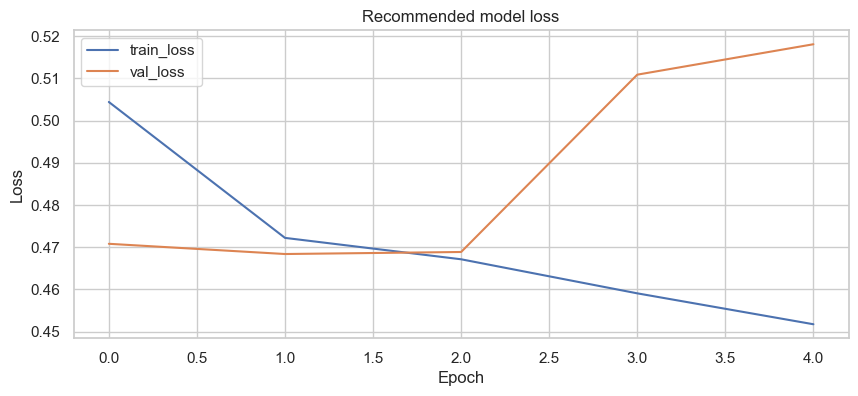

In [38]:
rec_history_df = pd.DataFrame(history_rec.history)

plt.figure(figsize=(10, 4))
plt.plot(rec_history_df["loss"], label="train_loss")
plt.plot(rec_history_df["val_loss"], label="val_loss")
plt.title("Recommended model loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [52]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

recommended_model_v2 = Sequential()
recommended_model_v2.add(Input(shape=(MAX_LEN,)))
recommended_model_v2.add(Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True))
recommended_model_v2.add(GRU(64))
recommended_model_v2.add(Dense(32, activation="relu"))
recommended_model_v2.add(Dropout(0.2))
recommended_model_v2.add(Dense(1, activation="sigmoid"))

recommended_model_v2.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [53]:
early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_rec_v2 = recommended_model_v2.fit(
    X_train_pad,
    y_train_rec,
    epochs=15,
    validation_data=(X_val_pad, y_val_rec),
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping_v2]
)

Epoch 1/15
177/177 - 9s - 52ms/step - accuracy: 0.8210 - loss: 0.4889 - val_accuracy: 0.8223 - val_loss: 0.4717
Epoch 2/15
177/177 - 6s - 35ms/step - accuracy: 0.8226 - loss: 0.4716 - val_accuracy: 0.8223 - val_loss: 0.4682
Epoch 3/15
177/177 - 6s - 34ms/step - accuracy: 0.8226 - loss: 0.4690 - val_accuracy: 0.8223 - val_loss: 0.4673
Epoch 4/15
177/177 - 6s - 36ms/step - accuracy: 0.8226 - loss: 0.4648 - val_accuracy: 0.8223 - val_loss: 0.4673
Epoch 5/15
177/177 - 6s - 36ms/step - accuracy: 0.8252 - loss: 0.4457 - val_accuracy: 0.8219 - val_loss: 0.3609
Epoch 6/15
177/177 - 6s - 34ms/step - accuracy: 0.8901 - loss: 0.2609 - val_accuracy: 0.8322 - val_loss: 0.3614
Epoch 7/15
177/177 - 6s - 32ms/step - accuracy: 0.9301 - loss: 0.1855 - val_accuracy: 0.8819 - val_loss: 0.3071
Epoch 8/15
177/177 - 6s - 32ms/step - accuracy: 0.9401 - loss: 0.1640 - val_accuracy: 0.8957 - val_loss: 0.2343
Epoch 9/15
177/177 - 6s - 36ms/step - accuracy: 0.9493 - loss: 0.1448 - val_accuracy: 0.8879 - val_loss:

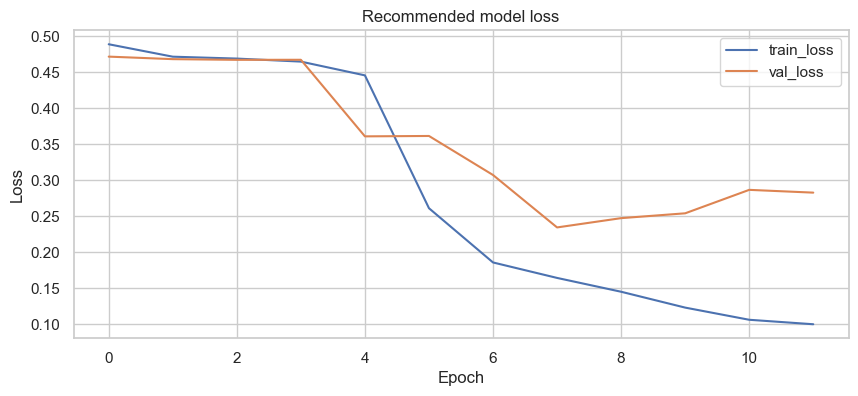

In [54]:
rec_history_v2_df = pd.DataFrame(history_rec_v2.history)

plt.figure(figsize=(10, 4))
plt.plot(rec_history_v2_df["loss"], label="train_loss")
plt.plot(rec_history_v2_df["val_loss"], label="val_loss")
plt.title("Recommended model loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [55]:
val_rec_pred_prob_v2 = recommended_model_v2.predict(X_val_pad, verbose=0).ravel()
val_rec_pred_label_v2 = (val_rec_pred_prob_v2 >= 0.5).astype(int)

In [56]:
pd.Series(val_rec_pred_prob_v2).describe()

count    2819.000000
mean        0.802262
std         0.297489
min         0.032979
25%         0.717221
50%         0.971946
75%         0.993110
max         0.999518
dtype: float64

In [57]:
pd.Series(val_rec_pred_label_v2).value_counts()

1    2262
0     557
Name: count, dtype: int64

In [58]:
pd.crosstab(
    pd.Series(y_val_rec, name="true"),
    pd.Series(val_rec_pred_label_v2, name="pred")
)

pred,0,1
true,,
0.0,382,119
1.0,175,2143


In [60]:
results_v2 = []

rating_options = {
    "rating_continuous": val_rating_pred_cont,
    "rating_rounded": val_rating_pred_round
}

rec_options = {
    "rec_probability_v2": val_rec_pred_prob_v2,
    "rec_hard_label_v2": val_rec_pred_label_v2
}

for rating_name, rating_pred in rating_options.items():
    for rec_name, rec_pred in rec_options.items():
        score_df = evaluate_predictions(
            y_val_rating, rating_pred,
            y_val_rec, rec_pred
        )
        mean_score = score_df.loc[score_df["target"] == "Mean", "spearman"].iloc[0]

        results_v2.append({
            "rating_prediction_type": rating_name,
            "recommended_prediction_type": rec_name,
            "mean_spearman": mean_score,
            "rating_spearman": score_df.loc[score_df["target"] == "Rating", "spearman"].iloc[0],
            "recommended_spearman": score_df.loc[score_df["target"] == "Recommended", "spearman"].iloc[0]
        })

results_df_v2 = pd.DataFrame(results_v2).sort_values("mean_spearman", ascending=False)
results_df_v2

,rating_prediction_type,recommended_prediction_type,mean_spearman,rating_spearman,recommended_spearman
1,rating_continuous,rec_hard_label_v2,0.677807,0.696068,0.659546
3,rating_rounded,rec_hard_label_v2,0.676643,0.693740,0.659546
0,rating_continuous,rec_probability_v2,0.639993,0.696068,0.583917
2,rating_rounded,rec_probability_v2,0.638829,0.693740,0.583917


Full final fit of the model

In [61]:
X_full_text = train_p["full_text"].values
X_test_text = test_p["full_text"].values

final_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
final_tokenizer.fit_on_texts(X_full_text)

X_full_seq = final_tokenizer.texts_to_sequences(X_full_text)
X_test_seq = final_tokenizer.texts_to_sequences(X_test_text)

X_full_pad = pad_sequences(X_full_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad_final = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

final_vocab_size = min(MAX_WORDS, len(final_tokenizer.word_index) + 1)

print("Final vocab size:", final_vocab_size)
print("X_full_pad shape:", X_full_pad.shape)
print("X_test_pad_final shape:", X_test_pad_final.shape)

Final vocab size: 12257
X_full_pad shape: (14091, 109)
X_test_pad_final shape: (9395, 109)


In [62]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

final_rating_model = Sequential()
final_rating_model.add(Input(shape=(MAX_LEN,)))
final_rating_model.add(Embedding(input_dim=final_vocab_size, output_dim=64, mask_zero=True))
final_rating_model.add(GRU(64))
final_rating_model.add(Dense(32, activation="relu"))
final_rating_model.add(Dropout(0.3))
final_rating_model.add(Dense(1, activation="linear"))

final_rating_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

final_rating_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 109, 64)        │       784,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 811,521 (3.10 MB)

 Trainable params: 811,521 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
final_recommended_model = Sequential()
final_recommended_model.add(Input(shape=(MAX_LEN,)))
final_recommended_model.add(Embedding(input_dim=final_vocab_size, output_dim=64, mask_zero=True))
final_recommended_model.add(GRU(64))
final_recommended_model.add(Dense(32, activation="relu"))
final_recommended_model.add(Dropout(0.2))
final_recommended_model.add(Dense(1, activation="sigmoid"))

final_recommended_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_recommended_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 109, 64)        │       784,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 811,521 (3.10 MB)

 Trainable params: 811,521 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [67]:
final_history_rating = final_rating_model.fit(
    X_full_pad,
    train_p["Rating"].values.astype("float32"),
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    verbose=2,
    callbacks=[final_early_stopping]
)

Epoch 1/15
199/199 - 8s - 40ms/step - loss: 0.5475 - mae: 0.5792 - val_loss: 0.4848 - val_mae: 0.5007
Epoch 2/15
199/199 - 7s - 35ms/step - loss: 0.5120 - mae: 0.5573 - val_loss: 0.5211 - val_mae: 0.4992
Epoch 3/15
199/199 - 7s - 33ms/step - loss: 0.4914 - mae: 0.5493 - val_loss: 0.5130 - val_mae: 0.4964
Epoch 4/15
199/199 - 7s - 34ms/step - loss: 0.4639 - mae: 0.5344 - val_loss: 0.4989 - val_mae: 0.5147


In [68]:
final_history_rec = final_recommended_model.fit(
    X_full_pad,
    train_p["Recommended"].values.astype("float32"),
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    verbose=2,
    callbacks=[final_early_stopping]
)

Epoch 1/15
199/199 - 7s - 36ms/step - accuracy: 0.8230 - loss: 0.4806 - val_accuracy: 0.8177 - val_loss: 0.4789
Epoch 2/15
199/199 - 6s - 32ms/step - accuracy: 0.8230 - loss: 0.4707 - val_accuracy: 0.8177 - val_loss: 0.4772
Epoch 3/15
199/199 - 7s - 37ms/step - accuracy: 0.8230 - loss: 0.4660 - val_accuracy: 0.8177 - val_loss: 0.4761
Epoch 4/15
199/199 - 6s - 32ms/step - accuracy: 0.8233 - loss: 0.4588 - val_accuracy: 0.8177 - val_loss: 0.4675
Epoch 5/15
199/199 - 6s - 32ms/step - accuracy: 0.8817 - loss: 0.2816 - val_accuracy: 0.8865 - val_loss: 0.2608
Epoch 6/15
199/199 - 7s - 34ms/step - accuracy: 0.9297 - loss: 0.1807 - val_accuracy: 0.8957 - val_loss: 0.2375
Epoch 7/15
199/199 - 6s - 31ms/step - accuracy: 0.9502 - loss: 0.1429 - val_accuracy: 0.8950 - val_loss: 0.2558
Epoch 8/15
199/199 - 7s - 33ms/step - accuracy: 0.9638 - loss: 0.1136 - val_accuracy: 0.8929 - val_loss: 0.2893
Epoch 9/15
199/199 - 10s - 48ms/step - accuracy: 0.9709 - loss: 0.0966 - val_accuracy: 0.8844 - val_loss

In [69]:
test_rating_pred_cont = final_rating_model.predict(X_test_pad_final, verbose=0).ravel()
test_rating_pred_round = np.clip(np.rint(test_rating_pred_cont), 1, 5).astype(int)

test_rec_pred_prob = final_recommended_model.predict(X_test_pad_final, verbose=0).ravel()
test_rec_pred_label = (test_rec_pred_prob >= 0.5).astype(int)

In [70]:
submission_rnn_v2 = pd.DataFrame({
    "Id": test_p["Id"].astype(int),
    "Rating": test_rating_pred_round.astype(int),
    "Recommended": test_rec_pred_label.astype(int)
})

submission_rnn_v2.head()

,Id,Rating,Recommended
0,21403,5,1
1,22553,3,0
2,17436,4,1
3,4293,5,1
4,20149,4,1


In [71]:
print(submission_rnn_v2.shape)
print(submission_rnn_v2.dtypes)
print(submission_rnn_v2.isna().sum())

display(submission_rnn_v2.head())
display(submission_rnn_v2["Rating"].value_counts().sort_index())
display(submission_rnn_v2["Recommended"].value_counts().sort_index())

(9395, 3)
Id             int64
Rating         int64
Recommended    int64
dtype: object
Id             0
Rating         0
Recommended    0
dtype: int64


,Id,Rating,Recommended
0,21403,5,1
1,22553,3,0
2,17436,4,1
3,4293,5,1
4,20149,4,1


Rating
1      30
2     554
3    1113
4    2479
5    5219
Name: count, dtype: int64

Recommended
0    1704
1    7691
Name: count, dtype: int64

In [72]:
submission_rnn_v2.to_csv("submission_03_rnn_tensorflow_v2.csv", index=False)
print("Saved: submission_03_rnn_tensorflow_v2.csv")

Saved: submission_03_rnn_tensorflow_v2.csv
